In [1]:
%load_ext autoreload
%autoreload 2

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
from IPython.display import HTML
from rdkit.Chem import PandasTools
import pandas as pd

def displaydf(df):
    return HTML(df.to_html(notebook=True))

ddir = 'data/'
df = pd.read_csv(os.path.join(ddir,'partial_data.csv'))
df.columns = ['smiles']
display(df)

PandasTools.AddMoleculeColumnToFrame(df,'smiles','molecule',includeFingerprints=False)
# displaydf(df.head(2))

,smiles
0,c1c(N2C(=O)N3CC(N(CC)Cc4cccc(-c5ccc(C#N)cc5)c4...
1,c1(S(=O)(=O)N(CC)CC)c(C)ccc(C(=O)Nc2ccc(Cl)cn2)c1
2,c1c2oc(-c3cc(O)c(O)c(O)c3)c(OC3C(O)C(O)C(O)C(C...
3,C(c1nc(-c2cccc(NC(=O)c3ccc(C)s3)c2)oc1C)NC(=O)...
4,N(c1ccccc1)C(=O)c1cn(-c2ccccc2)nc1-c1ccc(Cl)cc1
...,...
995,CN(CC(=O)Nc1ccc(Cl)c(c1)C(F)(F)F)C(=O)CC1Sc2cc...
996,CCOc1nc2ccc(OCCC3CCN(CC3)c3ccc(C)nn3)cc2s1
997,CN(C1CS(=O)(=O)CC1)C(COc1ccccc1)=O
998,CCCC(=O)Nc1n[nH]c2cc(Cl)c(cc12)-c1ccc(CC)cc1


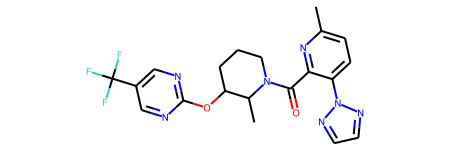

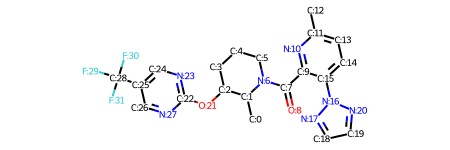

In [3]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True
from rdkit_utils import show_atom_index, get_rwmol, add_atom_to_mol

# smiles = 'CCCC(C)C' #df.smiles[6]
smiles = df.smiles[8]
mol = Chem.MolFromSmiles(smiles)
molgraph = get_rwmol(mol)
display(molgraph)
display(show_atom_index(mol))

# <font color=blue> First goal: "Add atom"

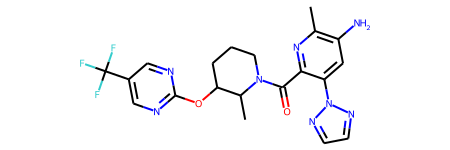

In [4]:
from rdkit.Chem.rdchem import RWMol, Atom, BondType

from rdkit_utils import *
def add_atom_to_mol(molgraph, atom_type, to_aidx): 
    update_mol_rep(molgraph)
    molgraph_new = copy_rwmol(molgraph)
    
    # add atom to mol object
    atom = Atom(atom_type)
    atom.SetBoolProp("mutability", True)    
    molgraph_new.AddAtom(atom)
    
    # create bond from new atom to source molecule
    molgraph_new.AddBond(molgraph_new.GetNumAtoms() - 1, to_aidx, BondType.SINGLE)
    
    update_mol_rep(molgraph_new)
    return molgraph_new

smiles = df.smiles[8] #'CCCC(C)C'
molgraph = get_rwmol( Chem.MolFromSmiles(smiles) )
molgraph_new = add_atom_to_mol(molgraph, 'N', 13)
display(molgraph_new)

16
Explicit valence for atom # 16 N, 4, is greater than permitted
0


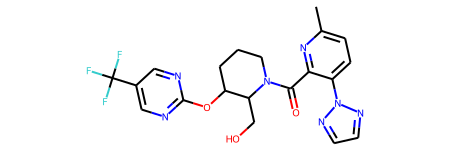

In [11]:
import numpy as np
import random
def randomly_add_atom(molgraph,atom_type='O'):
    idc = [i for i in range(0,(molgraph.GetNumAtoms()))]
    random.shuffle(idc)
    for i in idc:
        print(i)
        try:
            molgraph_new = add_atom_to_mol(molgraph, atom_type, i)
        except Exception as e:
            continue
        else:
            break
    else:
        return None
    return molgraph_new

smiles = df.smiles[8] #'CCCC(C)C'
molgraph = get_rwmol( Chem.MolFromSmiles(smiles) )
molgraph_new = randomly_add_atom(molgraph)
display(molgraph_new)

# <font color=blue> END-OF-NIGHT NOTES
So I got the "randomly add atom" function to work! It adds a single-bonded atom to some random atom index of mother molecule, resulting in a VALID molecule ... However ... I just had a thought ...
    
It seems that a single graph edit would be more meaningful to a 5-atom molecule than to a 100-atom molecule ... like ... can we honestly say that both versions result a pair of "similar" molecules? should we be considering total molecule size when deciding what a SINGLE graph edit entails ? ... idk ... just thoughts ...

In [ ]:
import random
import numpy as np

random.seed(666)

In [ ]:
def add_bond(self, from_atom, to_atom, update_rep=True):


    # Extracting current bond between given atoms
    curr_bond = self.mol_graph.GetBondBetweenAtoms(from_at, to_at)

    if curr_bond is None:
        self.mol_graph.AddBond(from_at, to_at, BondType.SINGLE)
        # print("Adding None -> Single bond between atoms of idx " + str(from_at) + " and " + str(to_at))
    elif Bond.GetBondType(curr_bond) == BondType.SINGLE:
        # print("Adding Single -> Double bond between atoms of idx " + str(from_at) + " and " + str(to_at))
        curr_bond.SetBondType(BondType.DOUBLE)
    elif Bond.GetBondType(curr_bond) == BondType.DOUBLE:
        # print("Adding Double -> Triple bond between atoms of idx " + str(from_at) + " and " + str(to_at))
        curr_bond.SetBondType(BondType.TRIPLE)

    else:
        print("Unknown bond type : " + self.to_smiles())
        raise Exception("Unknown bond type : " + self.to_smiles())

    if update_repr:
        # Updating internal representation
        self.evomol.update_mol_representation()

# <font color=blue> NOTES:
- Use `add_bond` later for bond editting !!! (line 205 of EvoMol_molgraph.py)
- In EvoMol's "actionspace" ... `action_id` = index on atoms !!!!